<a href="https://colab.research.google.com/github/sheekhaa/AI-worksheets/blob/main/2510348_BasantiKandel_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original dataset shape: (10000, 12)
Duplicates dropped by User_ID: 0
Exact duplicate rows dropped: 0


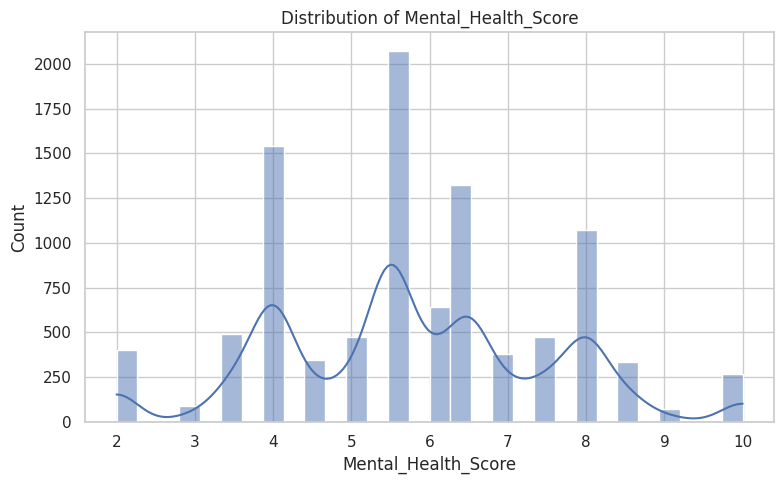

[Insight] Mental_Health_Score: mean=5.78, median=5.50, std=1.76, skew=0.10


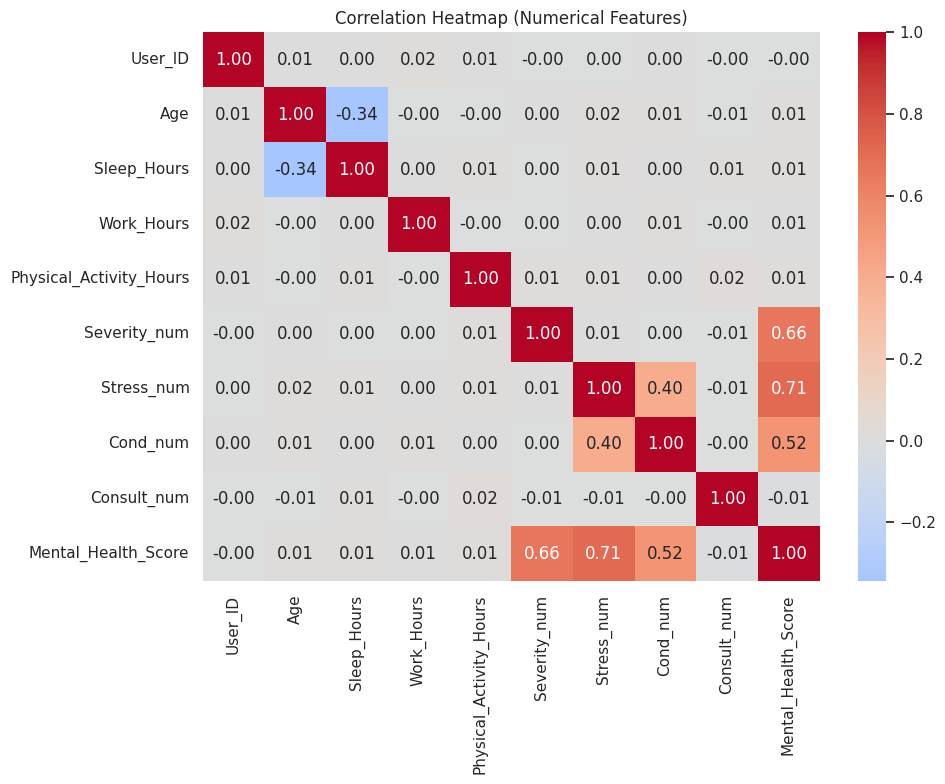

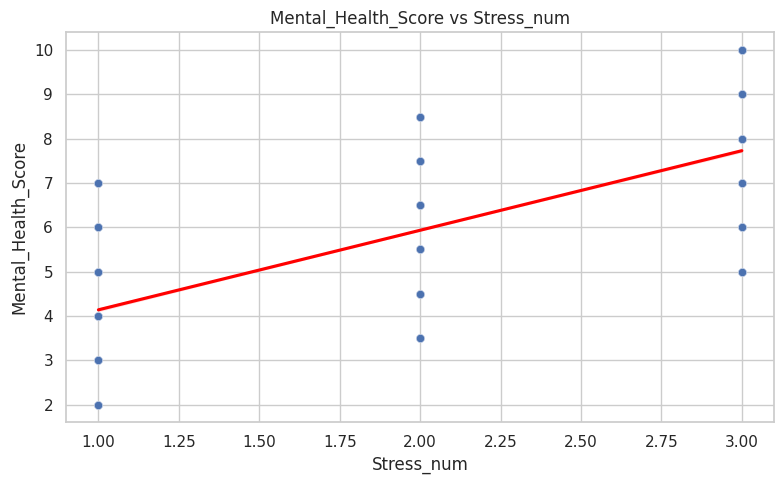

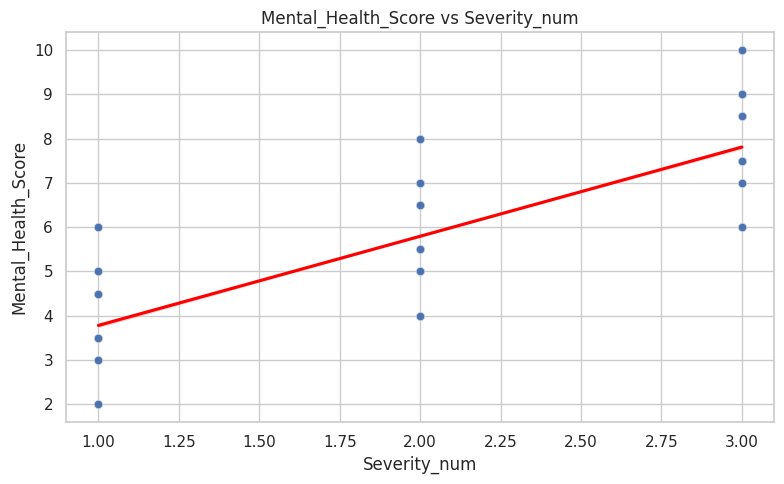

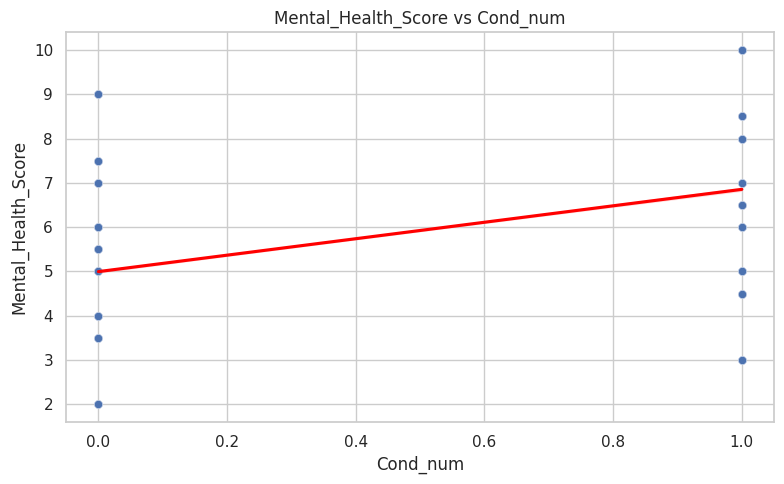

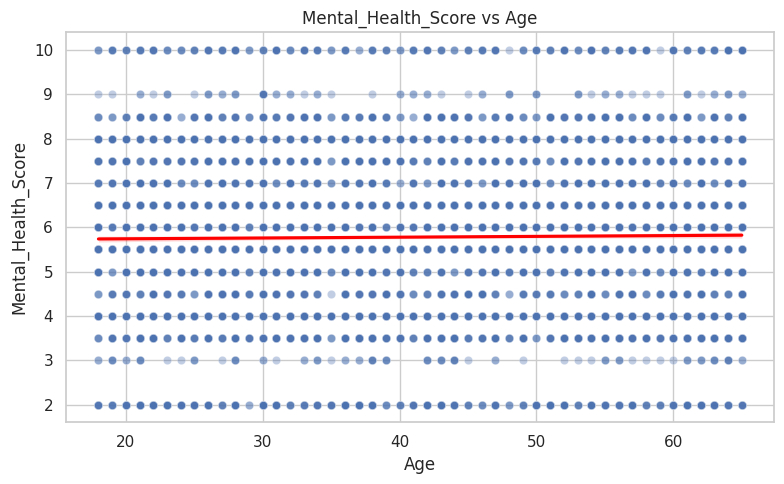

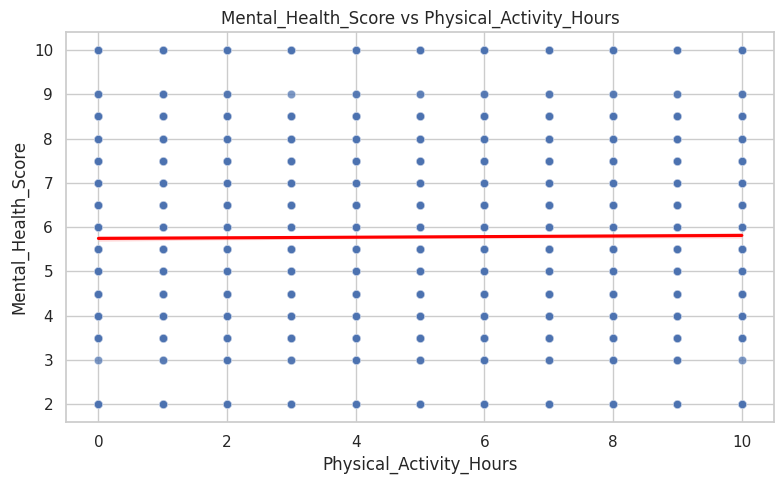

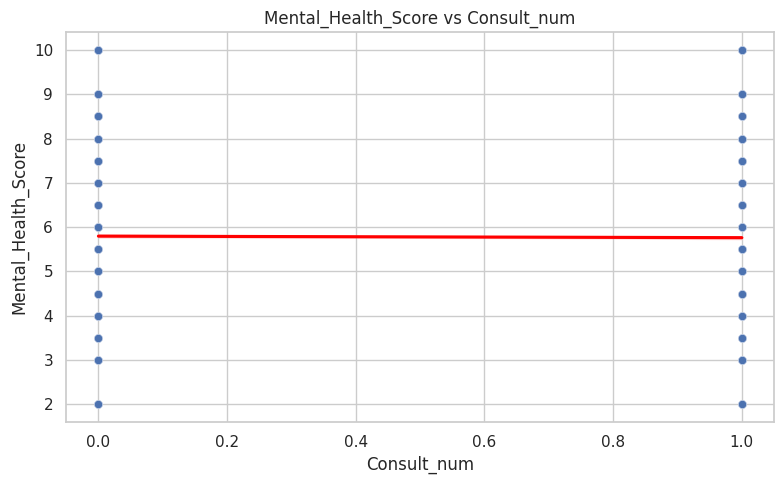

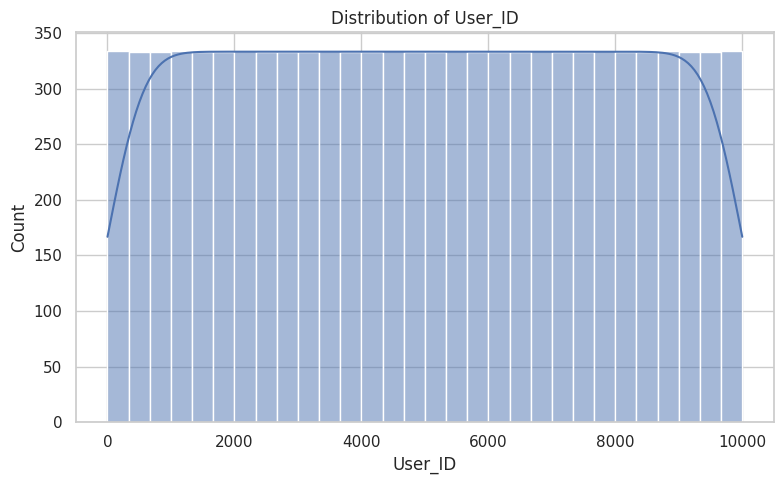

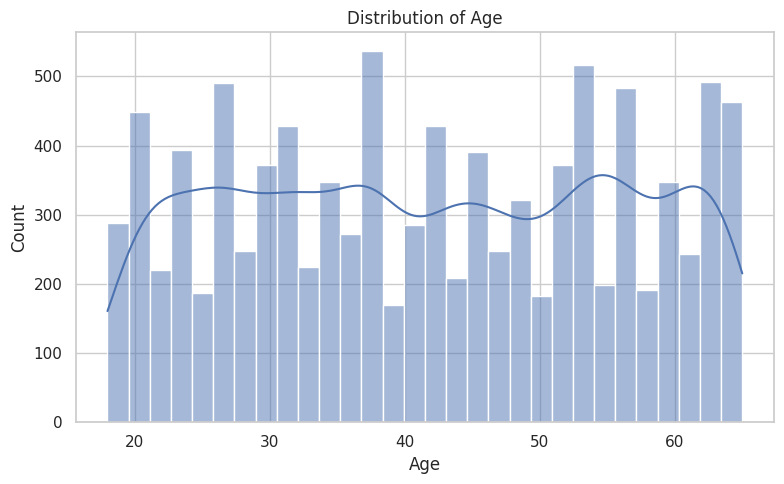

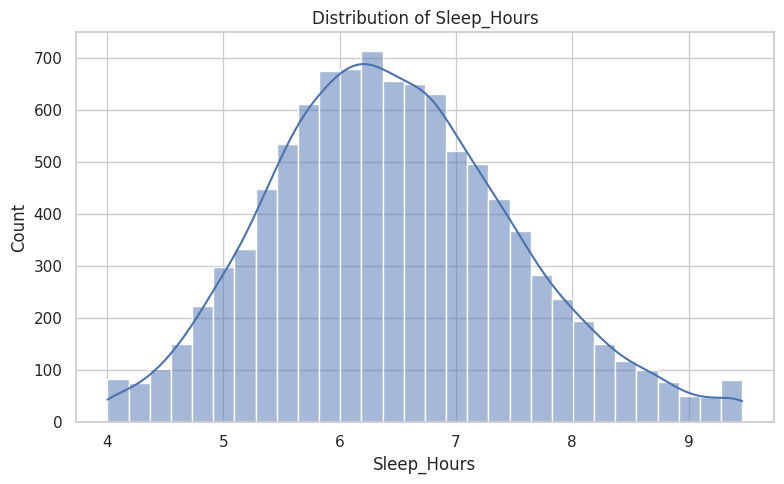

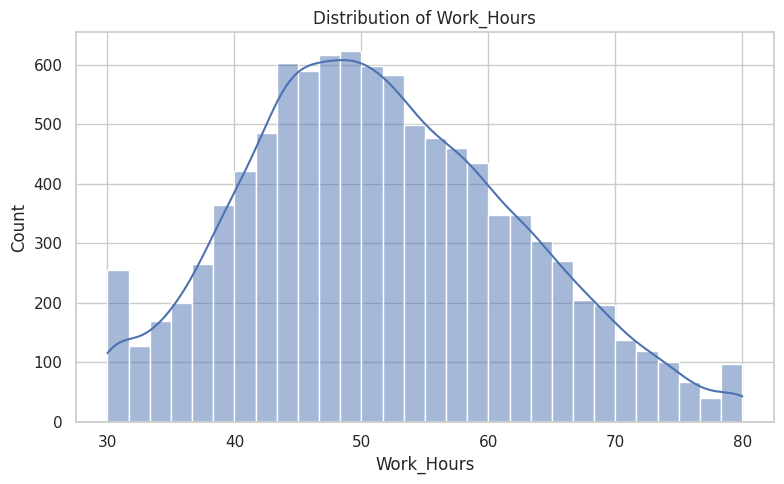

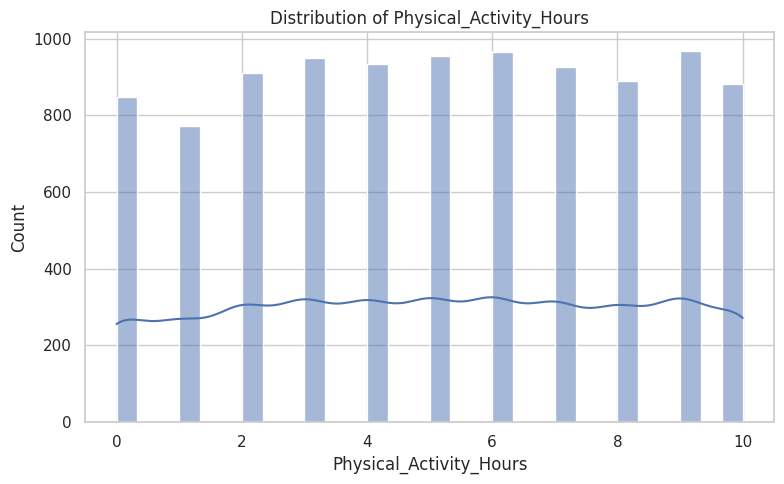

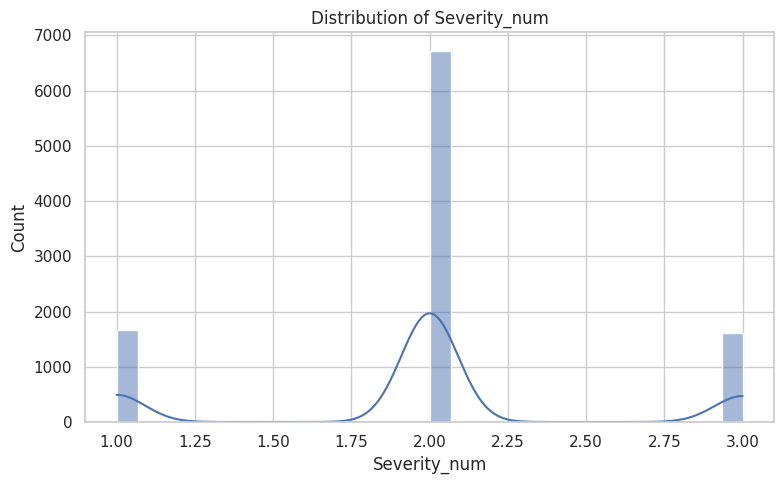

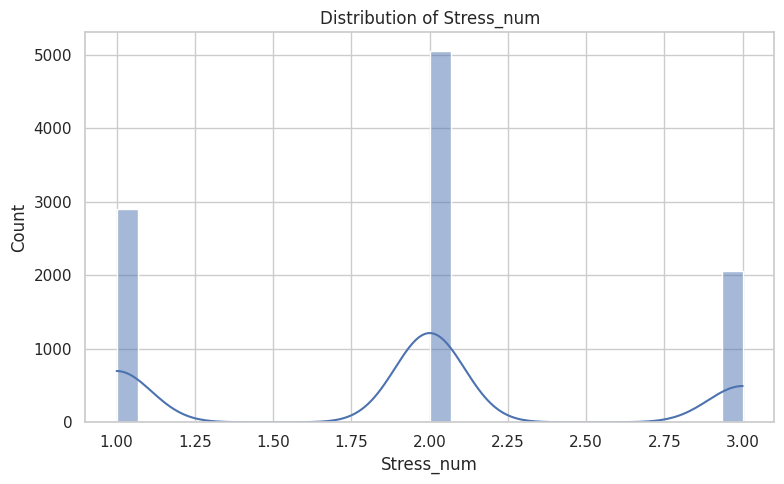

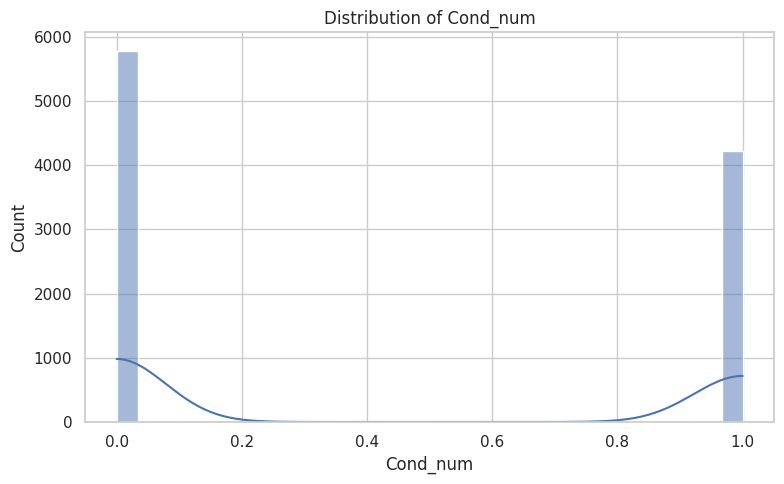

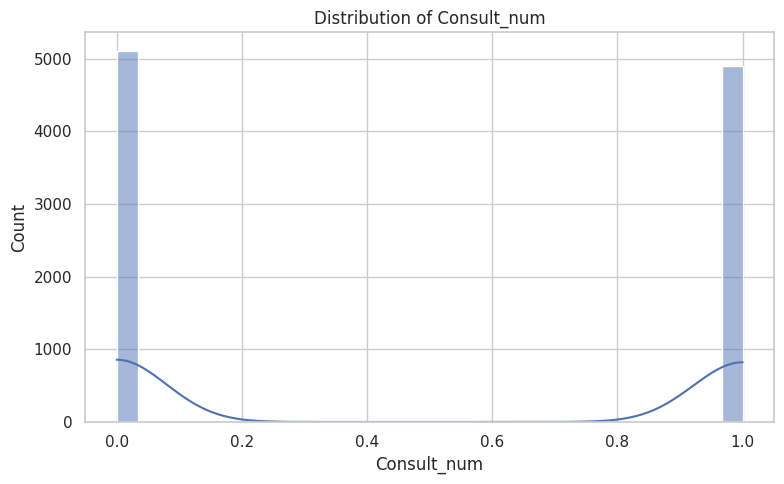

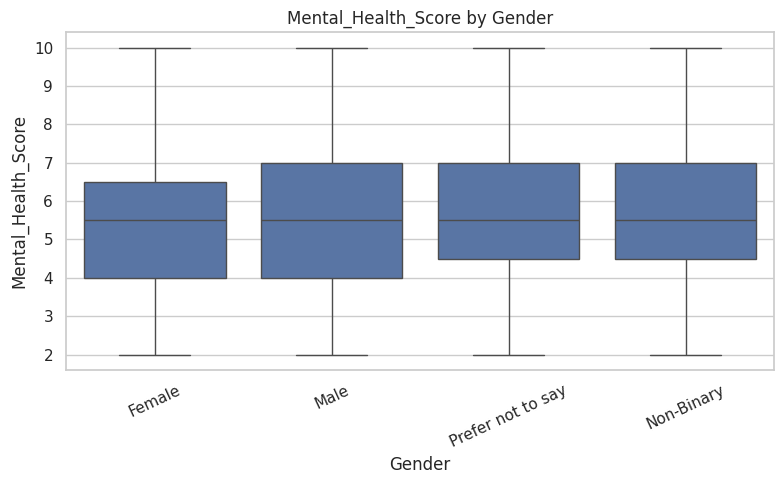

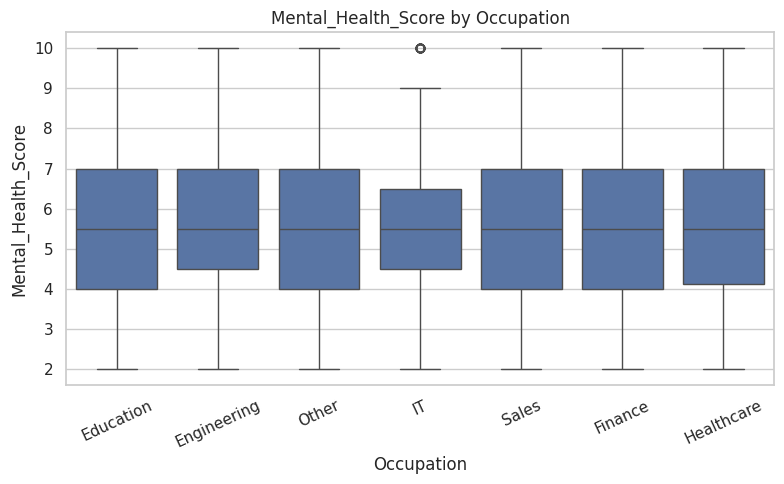

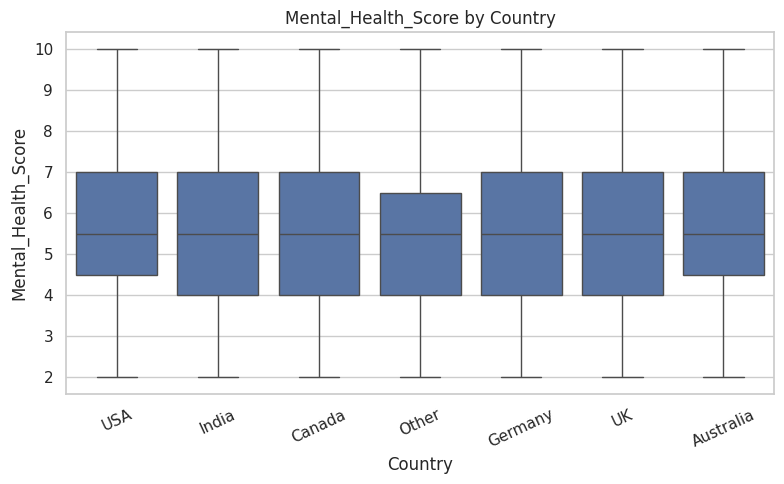

Cleaned dataset saved to: /content/drive/MyDrive/Colab Notebooks/Assignment-III/Datasets/reg_mental_health_cleaned.csv


In [7]:
# ============================================
# EDA + CLEANING (Mental Health Score Regression)
# ============================================

# ---- 0) Imports & settings ----
%matplotlib inline

import warnings, re
warnings.filterwarnings("ignore")# Ignore minor warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Plotting style
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42) # Reproducibility

# ---- 1) Load dataset ----
CSV_IN  = "/content/drive/MyDrive/Colab Notebooks/Assignment-III/Datasets/reg_mental_health_dataset.csv"
CSV_OUT = "/content/drive/MyDrive/Colab Notebooks/Assignment-III/Datasets/reg_mental_health_cleaned.csv"

df_raw = pd.read_csv(CSV_IN)
print(f"Original dataset shape: {df_raw.shape}")

df = df_raw.copy()# Work on a copy to preserve original

# ---- 2) Normalize column names & clean strings ----
# Remove spaces, BOM chars, and extra whitespace
df.columns = [re.sub(r"\s+", "_", c.strip().replace("\ufeff", "")) for c in df.columns]

for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()# Trim all string columns

# Replace common missing value tokens with NaN
missing_tokens = ['–','—','…','NA','N/A','','na','Na','None','none','Unknown','unknown']
df.replace(missing_tokens, np.nan, inplace=True)

# ---- 3) Ensure all expected columns exist ----
expected = [
    "User_ID","Age","Gender","Occupation","Country",
    "Mental_Health_Condition","Severity","Consultation_History",
    "Stress_Level","Sleep_Hours","Work_Hours","Physical_Activity_Hours"
]
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

# ---- 4) Convert near-numeric object columns to numeric ----
categorical_known = {
    "Gender","Occupation","Country","Mental_Health_Condition",
    "Severity","Consultation_History","Stress_Level"
}
for col in df.columns:
    if df[col].dtype == "object" and col not in categorical_known:
        probe = pd.to_numeric(df[col], errors="coerce")
        # FIX: use >= (not &gt;)
        if (1 - probe.isna().mean()) >= 0.90:  # If >90% values are numeric
            df[col] = probe # Convert to numeric

# ---- 5) Normalize categorical labels ----
def norm_label(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s.lower() == "prefer not to say":
        return "Prefer not to say"
    return s.title()

for c in ["Gender","Consultation_History","Stress_Level",
          "Mental_Health_Condition","Severity","Occupation","Country"]:
    df[c] = df[c].apply(norm_label)

# Normalize country names
_country_map = {"Usa":"USA","U.s.a.":"USA","United States":"USA","U.s.":"USA",
                "Uk":"UK","U.k.":"UK"}

def normalize_country(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s in _country_map: return _country_map[s]
    if s.lower() in {"uk","usa"}: return s.upper()
    return s.title()

df["Country"] = df["Country"].apply(normalize_country)

# Normalize occupation names
def normalize_occupation(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s.lower() in {"it","i.t.","information technology"}:
        return "IT"
    return s.title()

df["Occupation"] = df["Occupation"].apply(normalize_occupation)

# ---- 6) Clean categorical values ----
# Only allow expected levels; invalid values → NaN
severity_allowed = {"None","Low","Medium","High"}
stress_allowed   = {"Low","Medium","High"}
cond_allowed     = {"No","Yes"}
yn_allowed       = {"No","Yes"}

df.loc[~df["Stress_Level"].isin(stress_allowed), "Stress_Level"] = np.nan
df.loc[~df["Mental_Health_Condition"].isin(cond_allowed), "Mental_Health_Condition"] = np.nan
df.loc[~df["Consultation_History"].isin(yn_allowed), "Consultation_History"] = np.nan
df.loc[~df["Severity"].isin(severity_allowed), "Severity"] = np.nan

# ---- 7) Numeric bounds ----
# Remove impossible values
bounds = {
    "Age": (18,65),
    "Sleep_Hours": (0,12),
    "Work_Hours": (20,90),
    "Physical_Activity_Hours": (0,24)
}
for col, (lo, hi) in bounds.items():
    df[col] = pd.to_numeric(df[col], errors="coerce")
    # FIX: use < and > (not &lt; / &gt;)
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan

# ---- 8) Drop duplicates ----
before = len(df)
df = df.drop_duplicates(subset=["User_ID"], keep="first")
print(f"Duplicates dropped by User_ID: {before - len(df)}")
before = len(df)
df = df.drop_duplicates()
print(f"Exact duplicate rows dropped: {before - len(df)}")

# ---- 9) Split numeric vs categorical ----
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

# ---- 10) Impute missing values ----
# Numeric → median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → mode
for col in cat_cols:
    mode = df[col].mode(dropna=True)
    df[col] = df[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

# ---- 11) Encode categorical features numerically ----
severity_map = {"None":0,"Low":1,"Medium":2,"High":3}
stress_map   = {"Low":1,"Medium":2,"High":3}
cond_map     = {"No":0,"Yes":1}
yn_map       = {"No":0,"Yes":1}

df["Severity_num"]  = df["Severity"].map(severity_map).astype(int)
df["Stress_num"]    = df["Stress_Level"].map(stress_map).astype(int)
df["Cond_num"]      = df["Mental_Health_Condition"].map(cond_map).astype(int)
df["Consult_num"]   = df["Consultation_History"].map(yn_map).astype(int)

# ---- 12) Construct target: Mental_Health_Score ----
# Weighted combination of severity, stress, condition
TARGET_COL = "Mental_Health_Score"
W_SEVERITY, W_STRESS, W_COND = 0.6, 0.3, 0.1
df[TARGET_COL] = 10 * (
    W_SEVERITY*(df["Severity_num"]/3.0) +
    W_STRESS  *((df["Stress_num"] - 1.0)/2.0) +
    W_COND    * df["Cond_num"]
)

# ---- 13) Winsorize numeric features (remove outliers) ----
clip_lo, clip_hi = 0.005, 0.995
exclude = {TARGET_COL, "User_ID", "Severity_num", "Stress_num", "Cond_num", "Consult_num"}
for c in df.select_dtypes(include=[np.number]).columns:
    if c in exclude:
        continue
    lo, hi = df[c].quantile([clip_lo, clip_hi])
    df[c] = df[c].clip(lo, hi)

# ---- 14) EDA + Visualizations ----

# Refresh numeric columns after engineered features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 14a) Target distribution
plt.figure()
sns.histplot(df[TARGET_COL], bins=30, kde=True)
plt.title(f"Distribution of {TARGET_COL}")
plt.tight_layout()
plt.show()

t = df[TARGET_COL]
print(f"[Insight] {TARGET_COL}: mean={t.mean():.2f}, median={t.median():.2f}, std={t.std():.2f}, skew={t.skew():.2f}")

# 14b) Correlation heatmap
corr = None
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Correlation Heatmap (Numerical Features)")
    plt.tight_layout()
    plt.show()

# 14c) Scatter plots for top correlations with target
if corr is not None and TARGET_COL in corr.columns:
    top_corrs = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).head(6).index.tolist()
    for col in top_corrs:
        plt.figure()
        sns.scatterplot(x=df[col], y=df[TARGET_COL], alpha=0.35)
        sns.regplot(x=df[col], y=df[TARGET_COL], scatter=False, color="red")
        plt.title(f"{TARGET_COL} vs {col}")
        plt.tight_layout()
        plt.show()

# 14d) Numeric distributions
for col in [c for c in num_cols if c != TARGET_COL]:
    plt.figure()
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# 14e) Target by low-cardinality categoricals (boxplots)
low_card_cats = [x for x in ["Gender","Occupation","Country"] if x in df.columns]
for c in low_card_cats:
    plt.figure()
    sns.boxplot(x=df[c], y=df[TARGET_COL])
    plt.title(f"{TARGET_COL} by {c}")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

# ---- 15) Save cleaned dataset ----
df.to_csv(CSV_OUT, index=False)
print(f"Cleaned dataset saved to: {CSV_OUT}")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# =========================================================
# Task 2: NEURAL NETWORK REGRESSION (MLP)
# =========================================================

import warnings
warnings.filterwarnings("ignore")  # suppress minor warnings

import numpy as np
import pandas as pd

# ML preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- 0) Load cleaned dataset ----
CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/Assignment-III/Datasets/reg_mental_health_cleaned.csv"
df = pd.read_csv(CSV_CLEAN)

TARGET_COL = "Mental_Health_Score"
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found in {CSV_CLEAN}."

print(f"Loaded cleaned dataset: {df.shape}")

# ---- 2) Drop ID-like and helper encoding columns ----
# IDs or precomputed feature encodings won't help the model
drop_cols = [c for c in ["User_ID", "Severity_num", "Stress_num", "Cond_num"] if c in df.columns]
X = df.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")
y = df[TARGET_COL].astype(float)

# ---- 3) Leakage policy ----
# To avoid "cheating", we can optionally drop features used to compute the target
NO_LEAKAGE = True

if NO_LEAKAGE:
    leak_cols = ["Severity", "Stress_Level", "Mental_Health_Condition"]
    X = X.drop(columns=[c for c in leak_cols if c in X.columns], errors="ignore")

print(f"Final feature set size: {X.shape[1]} columns")

# ---- 4) Identify numeric vs categorical features ----
num_cols = X.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

# ---- 5) Preprocessing pipeline ----
# Scale numeric features, one-hot encode categorical features
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,    # For sklearn >= 1.2
        min_frequency=0.01,     # Group rare categories
        max_categories=30
    )
except TypeError:
    # fallback for older sklearn versions
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),  # scale numerics
        ("cat", ohe, cat_cols),               # one-hot encode categoricals
    ],
    remainder="drop"
)

# ---- 6) MLP Regressor ----
# Architecture: 128 -> 64 -> 1 neurons
# Activation: ReLU | Output: Linear
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,               # L2 regularization
    learning_rate="adaptive",
    max_iter=600,
    early_stopping=True,      # stop training if validation loss doesn't improve
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

# Combine preprocessing + model into a single pipeline
model = Pipeline(steps=[
    ("preprocessing", preprocess),
    ("mlp_regressor", mlp)
])

# ---- 7) Train-test split (80/20) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ---- 8) Train the model ----
model.fit(X_train, y_train)

# ---- 9) Evaluate ----
def eval_metrics(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>5} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

print("\n=== Neural Network Regression (MLP) Performance ===")
print("Network architecture: Input -> Dense(128, ReLU) -> Dense(64, ReLU) -> Dense(1, Linear)")
print("Loss: MSE | Optimizer: Adam | L2 alpha=1e-4 | Early stopping=True\n")

eval_metrics("Train", y_train, model.predict(X_train))
eval_metrics("Test",  y_test,  model.predict(X_test))


Loaded cleaned dataset: (10000, 17)
Final feature set size: 9 columns
Numeric features: ['Age', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Consult_num']
Categorical features: ['Gender', 'Occupation', 'Country', 'Consultation_History']

=== Neural Network Regression (MLP) Performance ===
Network architecture: Input -> Dense(128, ReLU) -> Dense(64, ReLU) -> Dense(1, Linear)
Loss: MSE | Optimizer: Adam | L2 alpha=1e-4 | Early stopping=True

Train | MSE: 2.9874 | RMSE: 1.7284 | MAE: 1.3782 | R²: 0.0372
 Test | MSE: 3.1000 | RMSE: 1.7607 | MAE: 1.4114 | R²: -0.0244


In [9]:
# =========================================================
# CLASSICAL REGRESSION MODELS — Fixed sparse/dense handling
#   (1) Linear Regression  (sparse OHE + scaled numerics)
#   (2) Random Forest Regr (dense OHE, numerics passthrough)
# Target: Mental_Health_Score (CLEANED dataset)
# =========================================================

import warnings
warnings.filterwarnings("ignore")  # suppress all warnings for cleaner notebook output

import numpy as np
import pandas as pd

# ---- Scikit-learn imports for preprocessing, modeling, evaluation ----
from sklearn.model_selection import train_test_split  # for splitting dataset into train/test
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # scaling numeric features + OHE for categoricals
from sklearn.compose import ColumnTransformer  # apply different transformations to numeric/categorical columns
from sklearn.pipeline import Pipeline  # combine preprocessing + model into single workflow
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # regression evaluation metrics
from sklearn.linear_model import LinearRegression  # classical linear regression model
from sklearn.ensemble import RandomForestRegressor  # ensemble tree-based regression model

# ---- Load cleaned dataset (already includes Mental_Health_Score) ----
from google.colab import drive
drive.mount('/content/drive')  # mount Google Drive to access CSV

CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/Assignment-III/Datasets/reg_mental_health_cleaned.csv"
TARGET_COL = "Mental_Health_Score"

df = pd.read_csv(CSV_CLEAN)  # load cleaned CSV into pandas DataFrame
assert TARGET_COL in df.columns, f"Target '{TARGET_COL}' not found in the cleaned CSV."  # sanity check

print(f"Loaded cleaned dataset: {df.shape}")  # display shape of the dataset

# ---- Drop ID-like & helper encoding columns ----
drop_cols = [c for c in ["User_ID", "Severity_num", "Stress_num", "Cond_num"] if c in df.columns]
# drop ID and precomputed helper numeric columns to avoid leakage
X = df.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")  # features
y = df[TARGET_COL].astype("float32")  # target, converted to float32 for efficiency

# ---- Leakage policy (choose) ----
NO_LEAKAGE = True  # True => exclude Severity/Stress/Condition to prevent leaking information from target
if NO_LEAKAGE:
    leak_cols = ["Severity", "Stress_Level", "Mental_Health_Condition"]
    # drop columns that are directly part of the target calculation
    X = X.drop(columns=[c for c in leak_cols if c in X.columns], errors="ignore")

print(f"Final feature columns: {len(X.columns)}")  # number of remaining features

# ---- Dtype tidy for numerics ----
for c in X.select_dtypes(include=["int64","float64"]).columns:
    X[c] = X[c].astype("float32")  # convert numeric columns to float32 for memory efficiency

# ---- Identify feature types ----
num_cols = X.select_dtypes(include=["int32","int64","float32","float64"]).columns.tolist()
# numeric features: integers/floats
cat_cols = [c for c in X.columns if c not in num_cols]
# categorical features: all others

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

# ---- Preprocessors ----
# safeguards against rare categories & large cardinality (applies to OHE)
RARE_CAT_MIN_FREQ = 0.01  # any category appearing in <1% of rows will be grouped (if supported)
MAX_CATEGORIES = 30       # maximum allowed unique categories for OHE

# (A) Sparse preprocessor for Linear Regression
# Linear Regression can handle sparse matrices efficiently
try:
    ohe_sparse = OneHotEncoder(handle_unknown="ignore", sparse_output=True,
                               min_frequency=RARE_CAT_MIN_FREQ, max_categories=MAX_CATEGORIES)
except TypeError:  # fallback for older sklearn versions
    ohe_sparse = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess_sparse = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_cols),  # scale numeric features without centering (compatible with sparse)
        ("cat", ohe_sparse, cat_cols),  # one-hot encode categorical features
    ],
    remainder="drop",
    sparse_threshold=1.0  # force output to be sparse
)

# (B) Dense preprocessor for Random Forest
# Random Forests do not require scaling; pass numerics directly
try:
    ohe_dense = OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                              min_frequency=RARE_CAT_MIN_FREQ, max_categories=MAX_CATEGORIES)
except TypeError:
    ohe_dense = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess_dense = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),  # pass numeric features without scaling
        ("cat", ohe_dense, cat_cols),      # dense one-hot encoding for categorical features
    ],
    remainder="drop"
)

# ---- Train–Test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42  # 80% training, 20% testing
)

# ---- Define models ----
models = {
    # Linear Regression pipeline
    "Linear Regression": Pipeline([
        ("prep", preprocess_sparse),  # sparse preprocessing
        ("model", LinearRegression())  # linear regression model
    ]),
    # Random Forest pipeline
    "Random Forest Regressor": Pipeline([
        ("prep", preprocess_dense),  # dense preprocessing
        ("model", RandomForestRegressor(
            n_estimators=200,       # number of trees
            max_depth=12,           # maximum depth of each tree
            min_samples_leaf=3,     # minimum samples required at a leaf node
            random_state=42,        # for reproducibility
            n_jobs=-1               # parallelize across all cores
        ))
    ])
}

# ---- Evaluation metrics ----
def metrics(y_true, y_pred):
    """Compute basic regression metrics for given true/predicted values."""
    mse  = mean_squared_error(y_true, y_pred)  # mean squared error
    rmse = np.sqrt(mse)                        # root mean squared error
    r2   = r2_score(y_true, y_pred)           # R-squared (variance explained)
    mae  = mean_absolute_error(y_true, y_pred)  # mean absolute error
    return {"MSE": mse, "RMSE": rmse, "R2": r2, "MAE": mae}

# ---- Train & evaluate models ----
results = {}  # dictionary to store train/test metrics
print("\nPrimary ML Models — Regression Performance\n")

for name, pipe in models.items():
    pipe.fit(X_train, y_train)  # fit model on training set

    ytr = pipe.predict(X_train)  # predictions on training set
    yte = pipe.predict(X_test)   # predictions on test set

    tr = metrics(y_train, ytr)   # compute metrics on train
    te = metrics(y_test, yte)    # compute metrics on test
    results[name] = {"Train": tr, "Test": te}  # store results

    # print train/test metrics
    print(f"{name}")
    print(f"  Train | MSE: {tr['MSE']:.6f} | RMSE: {tr['RMSE']:.6f} | R²: {tr['R2']:.6f} | MAE: {tr['MAE']:.6f}")
    print(f"   Test | MSE: {te['MSE']:.6f} | RMSE: {te['RMSE']:.6f} | R²: {te['R2']:.6f} | MAE: {te['MAE']:.6f}\n")

# ---- Initial comparison (by Test RMSE) ----
# sort models by RMSE on test set to find best performing model
best = min(results.items(), key=lambda kv: kv[1]["Test"]["RMSE"])
print("Initial Model Comparison (by Test RMSE):")
for name, stats in sorted(results.items(), key=lambda kv: kv[1]["Test"]["RMSE"]):
    s = stats["Test"]
    print(f"  {name:22s} → RMSE: {s['RMSE']:.6f} | R²: {s['R2']:.6f} | MAE: {s['MAE']:.6f}")

print(f"\n→ Current winner by Test RMSE: **{best[0]}**")  # indicate best model based on test RMSE


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded cleaned dataset: (10000, 17)
Final feature columns: 9
Numeric features: ['Age', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Consult_num']
Categorical features: ['Gender', 'Occupation', 'Country', 'Consultation_History']

Primary ML Models — Regression Performance

Linear Regression
  Train | MSE: 3.092264 | RMSE: 1.758483 | R²: 0.003455 | MAE: 1.403714
   Test | MSE: 3.027756 | RMSE: 1.740045 | R²: -0.000506 | MAE: 1.397974

Random Forest Regressor
  Train | MSE: 2.199130 | RMSE: 1.482946 | R²: 0.291286 | MAE: 1.179871
   Test | MSE: 3.063126 | RMSE: 1.750179 | R²: -0.012193 | MAE: 1.407301

Initial Model Comparison (by Test RMSE):
  Linear Regression      → RMSE: 1.740045 | R²: -0.000506 | MAE: 1.397974
  Random Forest Regressor → RMSE: 1.750179 | R²: -0.012193 | MAE: 1.407301

→ Current winner by Test RMSE: **Linear Regression**


In [10]:
# =========================================================
# TASK 4: Hyperparameter Optimization — Cross-Validation
# Target : Mental_Health_Score (continuous 0..10)
# Models : Ridge (GridSearchCV) + RandomForest (RandomizedSearchCV)
# =========================================================

import warnings, json
warnings.filterwarnings("ignore")  # suppress runtime warnings for cleaner output

import numpy as np
import pandas as pd
import sklearn

# ---- Scikit-learn imports ----
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ---- Load cleaned dataset ----
CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/Assignment-III/Datasets/reg_mental_health_cleaned.csv"
TARGET_COL = "Mental_Health_Score"

df = pd.read_csv(CSV_CLEAN)  # load CSV
assert TARGET_COL in df.columns, f"Target '{TARGET_COL}' not found in the cleaned CSV."  # sanity check
print(f"Loaded cleaned dataset: {df.shape} | sklearn: {sklearn.__version__}")

# ---- Prepare features and target ----
# Drop helper numeric encodings and ID-like columns
drop_cols = [c for c in ["User_ID", "Severity_num", "Stress_num", "Cond_num"] if c in df.columns]
X = df.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")  # feature set
y = df[TARGET_COL].astype("float32")  # target as float32

# ---- Leakage policy ----
# True: exclude Severity/Stress_Level/Mental_Health_Condition to prevent target leakage
# False: include them (upper-bound, reconstruct target)
NO_LEAKAGE = True
if NO_LEAKAGE:
    leak_cols = ["Severity", "Stress_Level", "Mental_Health_Condition"]
    X = X.drop(columns=[c for c in leak_cols if c in X.columns], errors="ignore")

print(f"Final features after leakage policy: {X.shape[1]} columns")

# ---- Identify numeric and categorical features ----
num_cols = X.select_dtypes(include=["int32","int64","float32","float64"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

# ---- Version-safe OneHotEncoder (dense) ----
def make_ohe_dense():
    """
    Returns a dense OneHotEncoder with safe fallback for older sklearn versions.
    dense: output as dense array (not sparse)
    handle_unknown="ignore": ignore unseen categories in test set
    min_frequency: group rare categories < 1%
    max_categories: cap maximum categories
    """
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,   # sklearn >=1.2
            min_frequency=0.01,
            max_categories=30
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="ignore",
                sparse=False,
                min_frequency=0.01,
                max_categories=30
            )
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)

ohe_dense = make_ohe_dense()  # initialize dense OHE

# ---- Preprocessing pipelines ----
# Ridge Regression: scale numeric features + dense OHE for categoricals
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),  # scale numeric features
        ("cat", ohe_dense, cat_cols),         # dense OHE for categorical
    ],
    remainder="drop"
)

# Random Forest: numeric features passthrough (trees don't need scaling), dense OHE for categorical
preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", ohe_dense, cat_cols),
    ],
    remainder="drop"
)

# ---- Train–Test split (80/20) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ---- Evaluation helper ----
def evaluate(name, y_true, y_pred):
    """
    Compute standard regression metrics and print.
    Returns RMSE, R2, MAE for convenience.
    """
    mse  = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2   = float(r2_score(y_true, y_pred))
    mae  = float(mean_absolute_error(y_true, y_pred))
    print(f"{name:>15} | RMSE: {rmse:.6f} | R²: {r2:.6f} | MAE: {mae:.6f}")
    return rmse, r2, mae

# =========================================================
# 1) Ridge Regression — GridSearchCV (tune alpha)
# =========================================================
print("\n🔹 Hyperparameter tuning — Ridge Regression")

# Create Ridge pipeline: preprocessing + Ridge model
lr_pipeline = Pipeline([
    ("preprocess", preprocess_lr),
    ("model", Ridge(random_state=42)) if "random_state" in Ridge().get_params() else ("model", Ridge())
])

# Key hyperparameter: L2 regularization strength alpha
lr_params = {"model__alpha": [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]}

# GridSearchCV: exhaustive search over alpha values with 5-fold CV
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=5,
    scoring="neg_root_mean_squared_error",  # sklearn maximizes score, so negative RMSE
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)  # fit GridSearchCV

# Best hyperparameters and CV performance
print(f"Best Hyperparameters (Ridge): {lr_grid.best_params_}")
print(f"Best CV RMSE (Ridge): {-lr_grid.best_score_:.6f}")  # negate back to positive RMSE

# Test-set performance
y_pred_lr = lr_grid.predict(X_test)
print("Test Performance (Ridge):")
ridge_test_rmse, ridge_test_r2, ridge_test_mae = evaluate("Ridge (test)", y_test, y_pred_lr)

# =========================================================
# 2) Random Forest Regressor — RandomizedSearchCV
# =========================================================
print("\n🔹 Hyperparameter tuning — Random Forest (RandomizedSearchCV)")

# Pipeline: preprocessing + RF model
rf_pipeline = Pipeline([
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Define hyperparameter search space
rf_params = {
    "model__n_estimators": [100, 150, 250, 350],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 3, 5],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True, False]
}

# RandomizedSearchCV: sample 32 random combinations with 3-fold CV
rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=32,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_random.fit(X_train, y_train)  # fit RandomizedSearchCV

# Best hyperparameters and CV performance
print(f"Best Hyperparameters (RF): {rf_random.best_params_}")
print(f"Best CV RMSE (RF): {-rf_random.best_score_:.6f}")

# Test-set performance
y_pred_rf = rf_random.predict(X_test)
print("Test Performance (RF):")
rf_test_rmse, rf_test_r2, rf_test_mae = evaluate("RandomForest (test)", y_test, y_pred_rf)

# =========================================================
# 3) Summary Table — Test Set Comparison
# =========================================================
results = pd.DataFrame({
    "Model": ["Ridge", "RandomForest"],
    "Test_RMSE": [ridge_test_rmse, rf_test_rmse],
    "Test_R2":   [ridge_test_r2,   rf_test_r2],
    "Test_MAE":  [ridge_test_mae,  rf_test_mae]
}).sort_values("Test_RMSE")  # sort by RMSE (lower is better)

print("\nTask 4 — Test Set Comparison:")
print(results.to_string(index=False))


Loaded cleaned dataset: (10000, 17) | sklearn: 1.6.1
Final features after leakage policy: 9 columns
Numeric features: ['Age', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Consult_num']
Categorical features: ['Gender', 'Occupation', 'Country', 'Consultation_History']

🔹 Hyperparameter tuning — Ridge Regression
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Hyperparameters (Ridge): {'model__alpha': 100.0}
Best CV RMSE (Ridge): 1.763508
Test Performance (Ridge):
   Ridge (test) | RMSE: 1.739845 | R²: -0.000276 | MAE: 1.398150

🔹 Hyperparameter tuning — Random Forest (RandomizedSearchCV)
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Hyperparameters (RF): {'model__n_estimators': 250, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 8, 'model__bootstrap': True}
Best CV RMSE (RF): 1.763150
Test Performance (RF):
RandomForest (test) | RMSE: 1.741161 | R²: -0.001790 | MAE: 1.400103



In [11]:
import warnings
warnings.filterwarnings("ignore")  # suppress runtime warnings for cleaner output

import numpy as np
import pandas as pd

# ---- Scikit-learn imports ----
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# Load dataset
# =========================================================
CSV_CLEAN = "/content/drive/MyDrive/Colab Notebooks/Assignment-III/Datasets/reg_mental_health_cleaned.csv"
TARGET_COL = "Mental_Health_Score"

df = pd.read_csv(CSV_CLEAN)  # load cleaned dataset

# Drop target, ID, and helper numeric columns
X = df.drop(
    columns=[TARGET_COL, "User_ID", "Severity_num", "Stress_num", "Cond_num"],
    errors="ignore"
)
y = df[TARGET_COL].astype("float32")  # target as float32

# ---- Leakage control ----
# Remove original features that were used to compute the target
X = X.drop(
    columns=["Severity", "Stress_Level", "Mental_Health_Condition"],
    errors="ignore"
)

# =========================================================
# Feature types
# =========================================================
# Identify numeric and categorical columns
num_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

cat_cols = [c for c in X.columns if c not in num_cols]

# =========================================================
# Train–test split (80/20)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# =========================================================
# Version-safe OneHotEncoder
# =========================================================
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",  # ignore unseen categories in test set
        sparse_output=False       # dense output (sklearn >=1.2)
    )
except TypeError:  # fallback for older sklearn
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# =========================================================
# Preprocessing pipelines
# =========================================================
# Ridge: standardize numeric features, dense OHE for categorical
prep_ridge = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols)
    ]
)

# Random Forest: numeric features passthrough, dense OHE for categorical
prep_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", ohe, cat_cols)
    ]
)

# =========================================================
# 1️⃣ Ridge Regression — Recursive Feature Elimination (RFE)
# =========================================================
# Fit preprocessing
Xtr_lr = prep_ridge.fit_transform(X_train)
Xte_lr = prep_ridge.transform(X_test)

ridge_model = Ridge(alpha=100.0)  # Ridge regression with strong L2 penalty

# Determine number of features to select (10–30 or ~1/5 of total)
k_ridge = min(30, max(10, Xtr_lr.shape[1] // 5))

# Recursive Feature Elimination
rfe = RFE(
    estimator=ridge_model,
    n_features_to_select=k_ridge
)
rfe.fit(Xtr_lr, y_train)  # fit RFE

ridge_mask = rfe.support_  # boolean mask of selected features

# Fit Ridge on selected features
ridge_model.fit(Xtr_lr[:, ridge_mask], y_train)
ridge_pred = ridge_model.predict(Xte_lr[:, ridge_mask])

# Evaluate Ridge
ridge_rmse_fs = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2_fs = r2_score(y_test, ridge_pred)

print("Ridge Regression (RFE)")
print(f"Selected features: {ridge_mask.sum()} / {Xtr_lr.shape[1]}")
print(f"RMSE: {ridge_rmse_fs:.4f}")
print(f"R²  : {ridge_r2_fs:.4f}")

# =========================================================
# 2️⃣ Random Forest — Top-k Feature Importance
# =========================================================
# Fit preprocessing
Xtr_rf = prep_rf.fit_transform(X_train)
Xte_rf = prep_rf.transform(X_test)

# Random Forest model with tuned hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=250,          # number of trees
    max_depth=8,               # max tree depth
    min_samples_leaf=5,        # min samples in leaf
    max_features="log2",       # features considered per split
    random_state=42,
    n_jobs=-1                  # parallel computation
)

rf_model.fit(Xtr_rf, y_train)  # fit full RF
importances = rf_model.feature_importances_  # get feature importances

# Determine top-k features (10–30 or ~1/5 of total)
k_rf = min(30, max(10, len(importances) // 5))
rf_idx = np.argsort(importances)[::-1][:k_rf]  # indices of top-k features

# Refit RF on top-k features
rf_model.fit(Xtr_rf[:, rf_idx], y_train)
rf_pred = rf_model.predict(Xte_rf[:, rf_idx])

# Evaluate RF
rf_rmse_fs = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2_fs = r2_score(y_test, rf_pred)

print("\nRandom Forest (Top-k Importance)")
print(f"Selected features: {len(rf_idx)} / {Xtr_rf.shape[1]}")
print(f"RMSE: {rf_rmse_fs:.4f}")
print(f"R²  : {rf_r2_fs:.4f}")


Ridge Regression (RFE)
Selected features: 10 / 25
RMSE: 1.7399
R²  : -0.0004

Random Forest (Top-k Importance)
Selected features: 10 / 25
RMSE: 1.7416
R²  : -0.0023


In [12]:
# =========================================================
# Final Models using selected features + tuned hyperparameters
# =========================================================

from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Final Ridge Model
# ---------------------------------------------------------
# Initialize Ridge regression with tuned alpha from previous hyperparameter tuning
final_ridge = Ridge(alpha=100.0)

# Fit Ridge using only the features selected by RFE
final_ridge.fit(Xtr_lr[:, ridge_mask], y_train)

# Predict on the test set using the same selected features
ridge_final_pred = final_ridge.predict(Xte_lr[:, ridge_mask])

# Compute performance metrics
ridge_final_rmse = np.sqrt(mean_squared_error(y_test, ridge_final_pred))  # Root Mean Squared Error
ridge_final_r2 = r2_score(y_test, ridge_final_pred)                        # R-squared

# ---------------------------------------------------------
# Final Random Forest Model
# ---------------------------------------------------------
# Initialize Random Forest with tuned hyperparameters from RandomizedSearchCV
final_rf = RandomForestRegressor(
    n_estimators=250,       # number of trees
    max_depth=8,            # max depth of each tree
    min_samples_leaf=5,     # min samples required at a leaf node
    max_features="log2",    # number of features to consider at each split
    random_state=42,        # reproducible results
    n_jobs=-1               # use all cores for parallel computation
)

# Fit RF using only top-k features based on importance
final_rf.fit(Xtr_rf[:, rf_idx], y_train)

# Predict on the test set
rf_final_pred = final_rf.predict(Xte_rf[:, rf_idx])

# Compute performance metrics
rf_final_rmse = np.sqrt(mean_squared_error(y_test, rf_final_pred))
rf_final_r2 = r2_score(y_test, rf_final_pred)

# ---------------------------------------------------------
# Final Comparison Table (Assignment Format)
# ---------------------------------------------------------
# Create a Pandas DataFrame summarizing the results of both models
final_comparison = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest"],  # Model names
    "Features Used": [
        f"Selected ({ridge_mask.sum()})",           # Number of features Ridge used
        f"Selected ({len(rf_idx)})"                # Number of features RF used
    ],
    "CV RMSE": [1.7635, 1.7631],                   # Cross-validation RMSE from Task 4
    "Test RMSE": [ridge_final_rmse, rf_final_rmse], # Test RMSE using selected features
    "Test R-squared": [ridge_final_r2, rf_final_r2] # Test R² using selected features
})

# Print the final comparison table nicely
print("\nTable 2: Comparison of Final Regression Models\n")
print(final_comparison.to_string(index=False))



Table 2: Comparison of Final Regression Models

           Model Features Used  CV RMSE  Test RMSE  Test R-squared
Ridge Regression Selected (10)   1.7635   1.739943       -0.000388
   Random Forest Selected (10)   1.7631   1.741568       -0.002258
